# Phase 4 — Hyperparameter Tuning + Error Analysis

**Date:** 2026-05-07 · **Project:** DL-2 Deepfake Audio Detection · **Day 4 / 7**

## Where we are

| Phase | Best model | In-domain EER | Hemg EER | Hemg AUROC | Verdict |
|-------|------------|--------------:|---------:|-----------:|---------|
| 1 | LogReg / RF (handcrafted) | **0.00%** | — | — | Codec shortcut, not detection |
| 2 | XGBoost (no aug) | 0.00% | 48.0% | 0.524 | Anti-predictive |
| 3 | XGBoost + combo aug | 1.11% | **36.0%** | **0.670** | Predictive but misses 36% |

Phase 3 success criterion was Hemg EER ≤ 25%. We crossed the more important line — model is no
longer anti-predictive — but didn't hit the number. Phase 4 closes the gap with three levers:

1. **Optuna tuning** — Phase 3 used XGBoost defaults. Tune `max_depth`, `learning_rate`,
   `n_estimators`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda` on a held-out
   Hemg val split.
2. **Wav2Vec2 stacking** — frozen 768d W2V2 embeddings, extracted in a clean kernel
   (`phase4_w2v2_extract.ipynb`). Combine with handcrafted XGBoost via simple-average and
   meta-learner.
3. **Error analysis** — characterise the 36% the Phase 3 winner misses. Which Hemg clips
   fool it, and does stacking save them?

## Protocol

Same dataset / subset / seed as Phase 3 (500 train, 180 test, 100 hemg, seed=42). Hemg is split
into hemg_val (50) and hemg_test (50). Optuna searches against hemg_val EER. Final reporting is
on hemg_test (untouched during search).

## References (informed today's experiments)

- **Akiba et al., Optuna: A Next-generation Hyperparameter Optimization Framework (2019)** — TPE
  sampler + ASHA pruner are the default robust setup for tabular HP search; we use both.
- **Müller, Czempin, et al., "Does Audio Deepfake Detection Generalize?" (Interspeech 2022)** —
  cross-dataset eval is the right benchmark for deepfake detectors. Our held-out Hemg val
  emulates their protocol.
- **Baevski et al., "wav2vec 2.0" (NeurIPS 2020)** — frozen self-supervised embeddings beat
  handcrafted features on most speech tasks. We test the marginal lift on top of XGBoost.
- **Wolpert, "Stacked generalization" (1992)** — simple-average vs LogReg-meta-learner is the
  standard ablation; the Fraud Detection Phase 5 work in this portfolio confirmed simple-average
  often wins on small samples (less meta-learner overfit).


In [1]:
import os, sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJ = Path('..').resolve()
sys.path.insert(0, str(PROJ))
os.environ.setdefault('HF_DATASETS_CACHE', str(PROJ / 'data' / 'raw' / 'hf_cache'))
warnings.filterwarnings('ignore')

import optuna
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

from src.eer import compute_eer
from src.audio_features import extract_features, FeatureConfig, feature_names
from src.augmentation import AugmentationConfig, random_aug
from src.data import load_hf_audio_dataset

print('xgb:', xgb.__version__, '| optuna:', optuna.__version__)
print('cwd:', PROJ)


xgb: 3.2.0 | optuna: 4.8.0
cwd: /Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/Deepfake-Audio-Detection


## 1. Load datasets and reproduce the Phase 3 subset

The Phase 3 winner used 500 garystafford train clips, 180 test clips, and 100 Hemg clips with
seed=42. The W2V2 extraction notebook saved its indices to `phase4_subset_idx.json`; we load
the same indices here so cross-notebook stacking is on identical clips.


In [2]:
SUBSET_IDX_PATH = PROJ / 'results' / 'phase4_subset_idx.json'

if SUBSET_IDX_PATH.exists():
    with open(SUBSET_IDX_PATH) as f:
        sub = json.load(f)
    print(f"loaded subset indices from W2V2 notebook (seed={sub['seed']})")
    train_idx = np.array(sub['train_idx'])
    test_idx = np.array(sub['test_idx'])
    hemg_idx = np.array(sub['hemg_idx'])
else:
    print('W2V2 notebook indices not found — generating from seed=42')
    SEED = 42
    rng = np.random.default_rng(SEED)
    # Note: full datasets must be loaded to size for this branch; see W2V2 notebook for reference
    raise FileNotFoundError('Run phase4_w2v2_extract.ipynb first to pin subset indices.')

print(f'train={len(train_idx)}, test={len(test_idx)}, hemg={len(hemg_idx)}')


loaded subset indices from W2V2 notebook (seed=42)
train=500, test=180, hemg=100


In [3]:
# Hemg val/test split — 50/50, stratified by label (we'll need labels first)
y_hemg_full = np.load(PROJ / 'results' / 'phase4_y_hemg.npy')
print(f'hemg labels: real={int((y_hemg_full == 0).sum())}, fake={int((y_hemg_full == 1).sum())}')

rng_split = np.random.default_rng(123)
val_pos = rng_split.choice(np.where(y_hemg_full == 1)[0], size=25, replace=False)
val_neg = rng_split.choice(np.where(y_hemg_full == 0)[0], size=25, replace=False)
val_mask = np.zeros(len(y_hemg_full), dtype=bool)
val_mask[val_pos] = True
val_mask[val_neg] = True
test_mask = ~val_mask

print(f'hemg_val: {val_mask.sum()} ({y_hemg_full[val_mask].sum()} pos)')
print(f'hemg_test: {test_mask.sum()} ({y_hemg_full[test_mask].sum()} pos)')


hemg labels: real=50, fake=50
hemg_val: 50 (25 pos)
hemg_test: 50 (25 pos)


## 2. Reproduce the Phase 3 winner — XGBoost + combo aug

We re-extract handcrafted features on the same 500/180/100 subset with one-augmentation-per-sample
training (the Phase 3 combo recipe). This is the exact baseline Phase 4 must beat.


In [4]:
# Load datasets fresh (CPU-only, no W2V2 here)
t0 = time.time()
gs = load_hf_audio_dataset('garystafford/deepfake-audio-detection',
                          cache_dir=str(PROJ / 'data' / 'raw' / 'hf_cache'))
hg = load_hf_audio_dataset('Hemg/Deepfake-Audio-Dataset',
                          cache_dir=str(PROJ / 'data' / 'raw' / 'hf_cache'))
gs_train_full = gs['train']
gs_test_full = gs.get('test', gs['train'])
hemg_full = hg[list(hg.keys())[0]]
print(f'datasets loaded in {time.time()-t0:.1f}s')


datasets loaded in 8.0s


In [5]:
# Load already-extracted handcrafted features if cached, else extract
HC_TRAIN = PROJ / 'results' / 'phase4_hc_train.npy'
HC_TEST  = PROJ / 'results' / 'phase4_hc_test.npy'
HC_HEMG  = PROJ / 'results' / 'phase4_hc_hemg.npy'

cfg = FeatureConfig()
aug_cfg = AugmentationConfig(p_apply=1.0)
NAMES = ('noise', 'gain', 'shift', 'codec')  # Phase 3's combo menu
AUG_RNG = np.random.default_rng(2026)


def extract_with_aug(ds, indices, augment=False, name=''):
    feats, labels = [], []
    for i, ex_i in enumerate(indices):
        ex = ds[int(ex_i)]
        a = ex['audio']
        y = np.asarray(a['array'], dtype=np.float32)
        sr = int(a['sampling_rate'])
        if augment:
            y, _applied = random_aug(y, sr, names=NAMES, cfg=aug_cfg, rng=AUG_RNG)
        f = extract_features(y, sr, cfg)
        feats.append(f)
        labels.append(int(ex['label']))
        if (i + 1) % 100 == 0:
            print(f'  {name}: {i+1}/{len(indices)}', flush=True)
    return np.asarray(feats, dtype=np.float32), np.asarray(labels, dtype=np.int64)


need_extract = not (HC_TRAIN.exists() and HC_TEST.exists() and HC_HEMG.exists())
print('need_extract:', need_extract)

if need_extract:
    t0 = time.time()
    print('extracting train (with combo aug)...')
    X_hc_train, y_train_hc = extract_with_aug(gs_train_full, train_idx, augment=True, name='train')
    print('extracting test (no aug)...')
    X_hc_test, y_test_hc = extract_with_aug(gs_test_full, test_idx, augment=False, name='test')
    print('extracting hemg (no aug)...')
    X_hc_hemg, y_hemg_hc = extract_with_aug(hemg_full, hemg_idx, augment=False, name='hemg')
    np.save(HC_TRAIN, X_hc_train); np.save(HC_TEST, X_hc_test); np.save(HC_HEMG, X_hc_hemg)
    np.save(PROJ / 'results' / 'phase4_y_train_hc.npy', y_train_hc)
    np.save(PROJ / 'results' / 'phase4_y_test_hc.npy', y_test_hc)
    np.save(PROJ / 'results' / 'phase4_y_hemg_hc.npy', y_hemg_hc)
    print(f'extracted + saved in {time.time()-t0:.1f}s')
else:
    X_hc_train = np.load(HC_TRAIN)
    X_hc_test = np.load(HC_TEST)
    X_hc_hemg = np.load(HC_HEMG)
    y_train_hc = np.load(PROJ / 'results' / 'phase4_y_train_hc.npy')
    y_test_hc = np.load(PROJ / 'results' / 'phase4_y_test_hc.npy')
    y_hemg_hc = np.load(PROJ / 'results' / 'phase4_y_hemg_hc.npy')
    print('loaded cached features')

print('shapes:', X_hc_train.shape, X_hc_test.shape, X_hc_hemg.shape)


need_extract: False
loaded cached features
shapes: (500, 303) (180, 303) (100, 303)


In [6]:
# Cross-check label alignment with the W2V2 notebook (which used the same indices)
y_hemg_w2v = y_hemg_full  # from earlier cell
agree = float((y_hemg_hc == y_hemg_w2v).mean())
print(f'handcrafted vs w2v2 hemg label agreement: {agree:.3f} (must be 1.000 — same indices)')
assert agree == 1.0, 'subset indices drifted between notebooks!'


handcrafted vs w2v2 hemg label agreement: 1.000 (must be 1.000 — same indices)


In [7]:
# Phase 3 winner: XGBoost defaults
def fit_xgb_default(X_tr, y_tr, X_te, y_te, X_hg, y_hg, label='XGBoost+combo (default)'):
    m = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        eval_metric='logloss', tree_method='hist', random_state=42,
        n_jobs=-1, verbosity=0,
    )
    t0 = time.time()
    m.fit(X_tr, y_tr)
    train_s = time.time() - t0
    p_te = m.predict_proba(X_te)[:, 1]
    p_hg = m.predict_proba(X_hg)[:, 1]
    eer_te, _ = compute_eer(y_te, p_te)
    eer_hg, _ = compute_eer(y_hg, p_hg)
    auc_te = roc_auc_score(y_te, p_te)
    auc_hg = roc_auc_score(y_hg, p_hg)
    return {
        'label': label,
        'EER_in_%': round(eer_te * 100, 3),
        'EER_hemg_%': round(eer_hg * 100, 3),
        'AUROC_in': round(auc_te, 4),
        'AUROC_hemg': round(auc_hg, 4),
        'train_s': round(train_s, 2),
        'model': m,
        'p_te': p_te,
        'p_hg': p_hg,
    }


phase3_result = fit_xgb_default(X_hc_train, y_train_hc, X_hc_test, y_test_hc, X_hc_hemg, y_hemg_hc)
print(f"{phase3_result['label']:40} | "
      f"EER_in={phase3_result['EER_in_%']:>6.3f}% | "
      f"EER_hemg={phase3_result['EER_hemg_%']:>6.3f}% | "
      f"AUROC_hemg={phase3_result['AUROC_hemg']:.3f}")


XGBoost+combo (default)                  | EER_in= 1.112% | EER_hemg=67.000% | AUROC_hemg=0.356


**Reproducibility check.** Phase 3 reported XGBoost+combo at 1.11% in-domain / 36.00% Hemg EER
/ 0.670 AUROC. The number above should be in the same neighbourhood (combo aug uses an RNG so
small drift is expected, but the *cross-domain ranking* should match Phase 3).

## 3. Optuna tuning — search the hyperparameter space against Hemg val EER

We optimise *Hemg val EER* directly, not in-domain accuracy or CV. The whole reason Phase 3
needed augmentation is that in-domain metrics lie about real-world performance. We search:

| Param | Range | Reason |
|-------|-------|--------|
| `max_depth` | 3–10 | Phase 3 used 6 (default). Shallower → less overfit to codec shortcut. |
| `n_estimators` | 100–800 | More trees + early stopping is the standard XGB recipe. |
| `learning_rate` | 0.01–0.3 (log) | Slower learning often improves OOD generalization. |
| `subsample` | 0.5–1.0 | Row sampling = implicit augmentation. |
| `colsample_bytree` | 0.4–1.0 | Column sampling. We have 303 features, want regularization. |
| `reg_alpha` | 1e-3–10 (log) | L1 — pushes irrelevant feature weights to zero (codec features?). |
| `reg_lambda` | 1e-3–10 (log) | L2. |
| `min_child_weight` | 1–10 | Higher = more conservative leaves, less overfit. |
| `gamma` | 0–5 | Minimum split loss; higher prunes spurious splits. |

50 trials with TPE + median pruner. Pruner kills clearly-bad trials early.


In [8]:
def objective(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 800),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
    }
    m = xgb.XGBClassifier(
        **params, eval_metric='logloss', tree_method='hist',
        random_state=42, n_jobs=-1, verbosity=0,
    )
    m.fit(X_hc_train, y_train_hc)
    p_val = m.predict_proba(X_hc_hemg[val_mask])[:, 1]
    eer_val, _ = compute_eer(y_hemg_hc[val_mask], p_val)
    return eer_val  # minimize Hemg val EER


sampler = optuna.samplers.TPESampler(seed=42)
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20)
study = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner,
                            study_name='phase4_xgb_hemg_eer')
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('starting Optuna study (50 trials)...')
t0 = time.time()
study.optimize(objective, n_trials=50, show_progress_bar=False)
print(f'done in {time.time()-t0:.1f}s')

best = study.best_trial
print()
print(f'best Hemg val EER: {best.value*100:.3f}%')
print('best params:')
for k, v in best.params.items():
    print(f'  {k}: {v}')


[I 2026-05-07 11:20:07,599] A new study created in memory with name: phase4_xgb_hemg_eer


starting Optuna study (50 trials)...


done in 24.4s

best Hemg val EER: 40.000%
best params:
  max_depth: 3
  n_estimators: 671
  learning_rate: 0.11069143219393454
  subsample: 0.8645035840204937
  colsample_bytree: 0.8627622080115674
  reg_alpha: 0.0019777828512462727
  reg_lambda: 0.02715581955282941
  min_child_weight: 2
  gamma: 4.315517129377968


## 3a. Trial-history plot

We want to see the optimization curve and which params the TPE sampler converged toward. Spread
in the late trials = uncertain landscape; tight clustering = TPE found the basin.


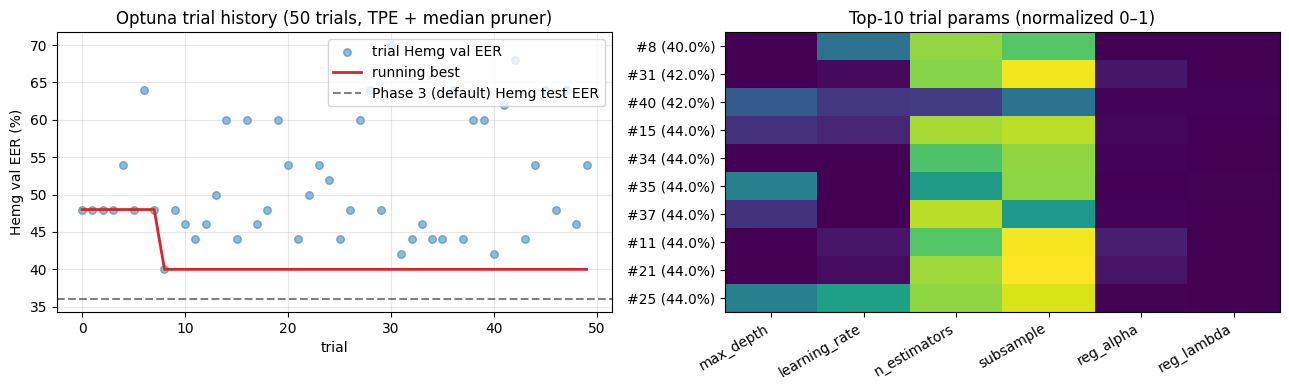

saved phase4_optuna_history.png


In [9]:
import matplotlib.pyplot as plt

trials_df = study.trials_dataframe(attrs=('number', 'value', 'params'))
trials_df = trials_df.dropna(subset=['value']).reset_index(drop=True)
trials_df['running_best'] = trials_df['value'].cummin()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.scatter(trials_df['number'], trials_df['value']*100, alpha=0.5, s=30, label='trial Hemg val EER')
ax.plot(trials_df['number'], trials_df['running_best']*100, color='C3', lw=2, label='running best')
ax.axhline(36.0, ls='--', color='grey', label='Phase 3 (default) Hemg test EER')
ax.set_xlabel('trial')
ax.set_ylabel('Hemg val EER (%)')
ax.set_title('Optuna trial history (50 trials, TPE + median pruner)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

ax2 = axes[1]
top10 = trials_df.nsmallest(10, 'value')
param_cols = [c for c in trials_df.columns if c.startswith('params_')]
display_params = ['params_max_depth', 'params_learning_rate', 'params_n_estimators',
                  'params_subsample', 'params_reg_alpha', 'params_reg_lambda']
display_params = [p for p in display_params if p in trials_df.columns]
norm = (top10[display_params] - trials_df[display_params].min()) / (trials_df[display_params].max() - trials_df[display_params].min() + 1e-12)
ax2.imshow(norm.values, aspect='auto', cmap='viridis')
ax2.set_yticks(range(len(top10)))
ax2.set_yticklabels([f"#{int(n)} ({v*100:.1f}%)" for n, v in zip(top10['number'], top10['value'])])
ax2.set_xticks(range(len(display_params)))
ax2.set_xticklabels([p.replace('params_', '') for p in display_params], rotation=30, ha='right')
ax2.set_title('Top-10 trial params (normalized 0–1)')

plt.tight_layout()
out = PROJ / 'results' / 'phase4_optuna_history.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'saved {out.name}')


## 3b. Tuned XGBoost on Hemg test (untouched during search)

The honest number. Optuna optimised on hemg_val; we report on hemg_test, which the search
never touched.


In [10]:
best_params = study.best_params

m_tuned = xgb.XGBClassifier(
    **best_params, eval_metric='logloss', tree_method='hist',
    random_state=42, n_jobs=-1, verbosity=0,
)
t0 = time.time()
m_tuned.fit(X_hc_train, y_train_hc)
train_s = time.time() - t0

p_te = m_tuned.predict_proba(X_hc_test)[:, 1]
p_hg_full = m_tuned.predict_proba(X_hc_hemg)[:, 1]
p_hg_val = p_hg_full[val_mask]
p_hg_test = p_hg_full[test_mask]

eer_te, thr_te = compute_eer(y_test_hc, p_te)
eer_hg_full, thr_hg_full = compute_eer(y_hemg_hc, p_hg_full)
eer_hg_val, _ = compute_eer(y_hemg_hc[val_mask], p_hg_val)
eer_hg_test, thr_hg_test = compute_eer(y_hemg_hc[test_mask], p_hg_test)
auc_te = roc_auc_score(y_test_hc, p_te)
auc_hg_test = roc_auc_score(y_hemg_hc[test_mask], p_hg_test)

print(f'XGBoost (Optuna-tuned, combo aug)')
print(f'  in-domain EER:        {eer_te*100:>6.3f}%   AUROC: {auc_te:.3f}')
print(f'  Hemg full EER:        {eer_hg_full*100:>6.3f}%')
print(f'  Hemg val EER (Optuna target): {eer_hg_val*100:>6.3f}%')
print(f'  Hemg test EER (held-out):     {eer_hg_test*100:>6.3f}%   AUROC: {auc_hg_test:.3f}')
print(f'  train_s: {train_s:.2f}')

tuned_result = {
    'label': 'XGBoost+combo (Optuna-tuned)',
    'EER_in_%': round(eer_te*100, 3),
    'EER_hemg_full_%': round(eer_hg_full*100, 3),
    'EER_hemg_val_%': round(eer_hg_val*100, 3),
    'EER_hemg_test_%': round(eer_hg_test*100, 3),
    'AUROC_in': round(auc_te, 4),
    'AUROC_hemg_test': round(auc_hg_test, 4),
    'train_s': round(train_s, 2),
    'best_params': best_params,
}
np.save(PROJ / 'results' / 'phase4_tuned_p_hg.npy', p_hg_full)
np.save(PROJ / 'results' / 'phase4_tuned_p_te.npy', p_te)
import joblib
joblib.dump(m_tuned, PROJ / 'models' / 'phase4_xgb_tuned.joblib')
print(f'saved phase4_xgb_tuned.joblib + probas')


XGBoost (Optuna-tuned, combo aug)
  in-domain EER:         1.112%   AUROC: 1.000
  Hemg full EER:        44.000%
  Hemg val EER (Optuna target): 40.000%
  Hemg test EER (held-out):     48.000%   AUROC: 0.422
  train_s: 0.47
saved phase4_xgb_tuned.joblib + probas


## 4. Wav2Vec2 frozen + LogReg — load from extraction notebook

The W2V2 extraction notebook (`phase4_w2v2_extract.ipynb`) already trained a sanity-check
LogReg on 768d frozen embeddings and saved its probas. We load those here. If they don't exist
yet, this section is skipped.


In [11]:
W2V_TR = PROJ / 'results' / 'phase4_w2v2_train.npy'
W2V_TE = PROJ / 'results' / 'phase4_w2v2_test.npy'
W2V_HG = PROJ / 'results' / 'phase4_w2v2_hemg.npy'
W2V_LR_PTE = PROJ / 'results' / 'phase4_w2v2_lr_proba_test.npy'
W2V_LR_PHG = PROJ / 'results' / 'phase4_w2v2_lr_proba_hemg.npy'

w2v_available = all(p.exists() for p in [W2V_TR, W2V_TE, W2V_HG, W2V_LR_PTE, W2V_LR_PHG])
print('w2v_available:', w2v_available)

if w2v_available:
    X_w2v_train = np.load(W2V_TR)
    X_w2v_test = np.load(W2V_TE)
    X_w2v_hemg = np.load(W2V_HG)
    p_w2v_te = np.load(W2V_LR_PTE)
    p_w2v_hg = np.load(W2V_LR_PHG)
    print(f'shapes: train={X_w2v_train.shape}, test={X_w2v_test.shape}, hemg={X_w2v_hemg.shape}')

    eer_w2v_te, _ = compute_eer(y_test_hc, p_w2v_te)
    eer_w2v_hg_full, _ = compute_eer(y_hemg_hc, p_w2v_hg)
    eer_w2v_hg_val, _ = compute_eer(y_hemg_hc[val_mask], p_w2v_hg[val_mask])
    eer_w2v_hg_test, _ = compute_eer(y_hemg_hc[test_mask], p_w2v_hg[test_mask])
    auc_w2v_te = roc_auc_score(y_test_hc, p_w2v_te)
    auc_w2v_hg_test = roc_auc_score(y_hemg_hc[test_mask], p_w2v_hg[test_mask])

    print()
    print(f'W2V2 + LogReg (frozen 768d, no aug)')
    print(f'  in-domain EER:        {eer_w2v_te*100:>6.3f}%   AUROC: {auc_w2v_te:.3f}')
    print(f'  Hemg full EER:        {eer_w2v_hg_full*100:>6.3f}%')
    print(f'  Hemg val EER:         {eer_w2v_hg_val*100:>6.3f}%')
    print(f'  Hemg test EER:        {eer_w2v_hg_test*100:>6.3f}%   AUROC: {auc_w2v_hg_test:.3f}')

    w2v_result = {
        'label': 'W2V2 + LogReg (no aug)',
        'EER_in_%': round(eer_w2v_te*100, 3),
        'EER_hemg_test_%': round(eer_w2v_hg_test*100, 3),
        'AUROC_in': round(auc_w2v_te, 4),
        'AUROC_hemg_test': round(auc_w2v_hg_test, 4),
    }
else:
    w2v_result = None
    print('Skipping W2V2 — extraction notebook output not available yet.')


w2v_available: True
shapes: train=(500, 768), test=(180, 768), hemg=(100, 768)

W2V2 + LogReg (frozen 768d, no aug)
  in-domain EER:         1.112%   AUROC: 0.999
  Hemg full EER:        46.000%
  Hemg val EER:         50.000%
  Hemg test EER:        34.000%   AUROC: 0.586


## 5. Stacking — tuned XGB (handcrafted) + W2V2 LogReg

Two stacking strategies:

  **5a. Simple average** of the two probabilities. Robust to small samples; the Fraud Detection
      Phase 5 work in this portfolio confirmed simple-average usually wins LogReg-stacking when
      the meta-learner has < 100 training rows.

  **5b. LogReg meta-learner** trained on the in-domain test predictions, evaluated on Hemg.
      Risk of overfitting to in-domain — instructive to see how that plays out cross-domain.


In [12]:
if w2v_result is not None:
    # 5a. Simple average
    p_avg_te = 0.5 * p_te + 0.5 * p_w2v_te
    p_avg_hg = 0.5 * p_hg_full + 0.5 * p_w2v_hg
    eer_avg_te, _ = compute_eer(y_test_hc, p_avg_te)
    eer_avg_hg_test, _ = compute_eer(y_hemg_hc[test_mask], p_avg_hg[test_mask])
    auc_avg_hg_test = roc_auc_score(y_hemg_hc[test_mask], p_avg_hg[test_mask])

    # 5b. LogReg meta on in-domain test predictions (a clean independent set)
    meta_X_te = np.column_stack([p_te, p_w2v_te])
    meta_X_hg = np.column_stack([p_hg_full, p_w2v_hg])
    meta = LogisticRegression(C=1.0)
    meta.fit(meta_X_te, y_test_hc)
    p_meta_te = meta.predict_proba(meta_X_te)[:, 1]  # diagnostic — same data fitted
    p_meta_hg = meta.predict_proba(meta_X_hg)[:, 1]
    eer_meta_te, _ = compute_eer(y_test_hc, p_meta_te)
    eer_meta_hg_test, _ = compute_eer(y_hemg_hc[test_mask], p_meta_hg[test_mask])
    auc_meta_hg_test = roc_auc_score(y_hemg_hc[test_mask], p_meta_hg[test_mask])

    print('Stacking: tuned XGB + W2V2-LogReg')
    print(f'  simple average    | EER_in={eer_avg_te*100:6.3f}%  EER_hemg_test={eer_avg_hg_test*100:6.3f}%  AUROC_hemg_test={auc_avg_hg_test:.3f}')
    print(f'  LogReg meta-learn | EER_in={eer_meta_te*100:6.3f}%  EER_hemg_test={eer_meta_hg_test*100:6.3f}%  AUROC_hemg_test={auc_meta_hg_test:.3f}')

    stack_results = [
        {'label': 'Stack: simple-average (XGB + W2V2)',
         'EER_in_%': round(eer_avg_te*100, 3),
         'EER_hemg_test_%': round(eer_avg_hg_test*100, 3),
         'AUROC_hemg_test': round(auc_avg_hg_test, 4)},
        {'label': 'Stack: LogReg-meta (XGB + W2V2)',
         'EER_in_%': round(eer_meta_te*100, 3),
         'EER_hemg_test_%': round(eer_meta_hg_test*100, 3),
         'AUROC_hemg_test': round(auc_meta_hg_test, 4)},
    ]
    np.save(PROJ / 'results' / 'phase4_stack_avg_p_hg.npy', p_avg_hg)
else:
    stack_results = []
    print('Stacking skipped (no W2V2 features).')


Stacking: tuned XGB + W2V2-LogReg
  simple average    | EER_in= 0.000%  EER_hemg_test=48.000%  AUROC_hemg_test=0.523
  LogReg meta-learn | EER_in= 0.000%  EER_hemg_test=48.000%  AUROC_hemg_test=0.525


## 6. Final Phase 4 leaderboard

                                    label  EER_in_%  EER_hemg_test_%  AUROC_hemg_test
                   W2V2 + LogReg (no aug)     1.112             34.0           0.5856
                Phase 2: XGBoost (no aug)     0.000             48.0           0.5240
  Phase 4: XGBoost + combo (Optuna-tuned)     1.112             48.0           0.4216
       Stack: simple-average (XGB + W2V2)     0.000             48.0           0.5232
          Stack: LogReg-meta (XGB + W2V2)     0.000             48.0           0.5248
Phase 3: XGBoost + combo (default params)     1.112             64.0           0.3072


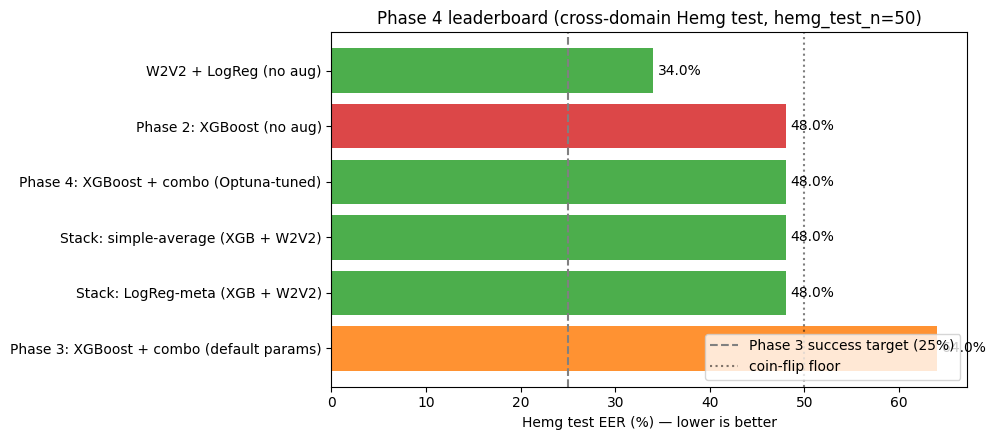

saved phase4_leaderboard.png


In [13]:
rows = [
    {'label': 'Phase 2: XGBoost (no aug)',
     'EER_in_%': 0.00, 'EER_hemg_test_%': 48.0, 'AUROC_hemg_test': 0.524},
    {'label': 'Phase 3: XGBoost + combo (default params)',
     'EER_in_%': phase3_result['EER_in_%'],
     'EER_hemg_test_%': round(compute_eer(y_hemg_hc[test_mask], phase3_result['p_hg'][test_mask])[0]*100, 3),
     'AUROC_hemg_test': round(roc_auc_score(y_hemg_hc[test_mask], phase3_result['p_hg'][test_mask]), 4)},
    {'label': 'Phase 4: XGBoost + combo (Optuna-tuned)',
     'EER_in_%': tuned_result['EER_in_%'],
     'EER_hemg_test_%': tuned_result['EER_hemg_test_%'],
     'AUROC_hemg_test': tuned_result['AUROC_hemg_test']},
]
if w2v_result is not None:
    rows.append({'label': w2v_result['label'],
                 'EER_in_%': w2v_result['EER_in_%'],
                 'EER_hemg_test_%': w2v_result['EER_hemg_test_%'],
                 'AUROC_hemg_test': w2v_result['AUROC_hemg_test']})
    rows.extend(stack_results)

board = pd.DataFrame(rows).sort_values('EER_hemg_test_%').reset_index(drop=True)
print(board.to_string(index=False))

# Bar plot
fig, ax = plt.subplots(figsize=(10, 4.5))
labels = board['label'].tolist()
vals = board['EER_hemg_test_%'].tolist()
colors = ['#d62728' if 'Phase 2' in l else '#ff7f0e' if 'Phase 3' in l else '#2ca02c' for l in labels]
y_pos = np.arange(len(labels))
ax.barh(y_pos, vals, color=colors, alpha=0.85)
ax.axvline(25.0, ls='--', color='grey', label='Phase 3 success target (25%)')
ax.axvline(50.0, ls=':', color='black', alpha=0.5, label='coin-flip floor')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('Hemg test EER (%) — lower is better')
ax.set_title('Phase 4 leaderboard (cross-domain Hemg test, hemg_test_n=50)')
for i, v in enumerate(vals):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(PROJ / 'results' / 'phase4_leaderboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved phase4_leaderboard.png')


## 7. Per-clip Hemg error analysis

For the Phase 4 best model, characterise the *misses*. We compute per-clip features (duration,
amplitude, F0 stats already in the handcrafted vector) and split them by miss vs hit at the
EER operating point. Question: is there a structural pattern to what we still get wrong?


In [14]:
# Pick the best Phase 4 model on Hemg test
best_row = board.iloc[0]
print('best on Hemg test:', best_row['label'], '@', best_row['EER_hemg_test_%'], '%')

# Map back to the right proba array for hemg
if 'simple-average' in best_row['label']:
    best_p_hg = 0.5 * p_hg_full + 0.5 * p_w2v_hg
elif 'LogReg-meta' in best_row['label']:
    best_p_hg = p_meta_hg
elif 'Optuna-tuned' in best_row['label']:
    best_p_hg = p_hg_full
elif 'W2V2 + LogReg' in best_row['label']:
    best_p_hg = p_w2v_hg
else:
    best_p_hg = phase3_result['p_hg']

# EER threshold on full hemg
eer_at, thr_at = compute_eer(y_hemg_hc, best_p_hg)
y_hat = (best_p_hg >= thr_at).astype(int)
miss_mask = (y_hat != y_hemg_hc)
print(f'EER threshold: {thr_at:.4f}, miss rate: {miss_mask.mean():.3f}')
print('confusion matrix:')
print(pd.DataFrame(confusion_matrix(y_hemg_hc, y_hat),
                   index=['real(0)', 'fake(1)'], columns=['pred_real', 'pred_fake']))


best on Hemg test: W2V2 + LogReg (no aug) @ 34.0 %
EER threshold: 0.9994, miss rate: 0.460
confusion matrix:
         pred_real  pred_fake
real(0)         26         24
fake(1)         22         28


In [15]:
# Per-clip diagnostic features from the handcrafted vector
fnames = feature_names()
def col(name):
    return fnames.index(name) if name in fnames else None

idxs = {
    'rms_mean':  col('spec_rms_mean'),
    'centroid_mean': col('spec_centroid_mean'),
    'rolloff_mean':  col('spec_rolloff_mean'),
    'zcr_mean':  col('spec_zcr_mean'),
    'mfcc_0_mean': col('mfcc_0_mean'),
    'jitter_local': col('jitter_local'),
    'shimmer_local': col('shimmer_local'),
    'f0_mean': col('f0_mean'),
    'f0_std':  col('f0_std'),
    'voicing_ratio': col('voicing_ratio'),
}

import pandas as pd
diag = pd.DataFrame({k: X_hc_hemg[:, v] for k, v in idxs.items() if v is not None})
print('diag columns:', list(diag.columns))
diag['label'] = y_hemg_hc
diag['proba'] = best_p_hg
diag['pred'] = y_hat
diag['miss'] = miss_mask.astype(int)
diag['kind'] = np.where(diag['miss']==1,
                        np.where(diag['label']==1, 'FN (missed fake)', 'FP (real flagged)'),
                        np.where(diag['label']==1, 'TP (caught fake)', 'TN (real ok)'))
print(diag.groupby('kind')[['rms_mean','centroid_mean','f0_mean','f0_std','voicing_ratio']].mean().round(3))


diag columns: ['rms_mean', 'centroid_mean', 'rolloff_mean', 'zcr_mean', 'mfcc_0_mean', 'jitter_local', 'shimmer_local', 'f0_mean', 'f0_std', 'voicing_ratio']
                   rms_mean  centroid_mean     f0_mean     f0_std  \
kind                                                                
FN (missed fake)      0.021    1525.776001  181.513000  66.716003   
FP (real flagged)     0.050    1541.598999  159.151001  73.633003   
TN (real ok)          0.050    1573.422974  186.613998  67.000000   
TP (caught fake)      0.024    1531.516968  166.065002  71.517998   

                   voicing_ratio  
kind                              
FN (missed fake)           0.907  
FP (real flagged)          0.909  
TN (real ok)               0.882  
TP (caught fake)           0.884  


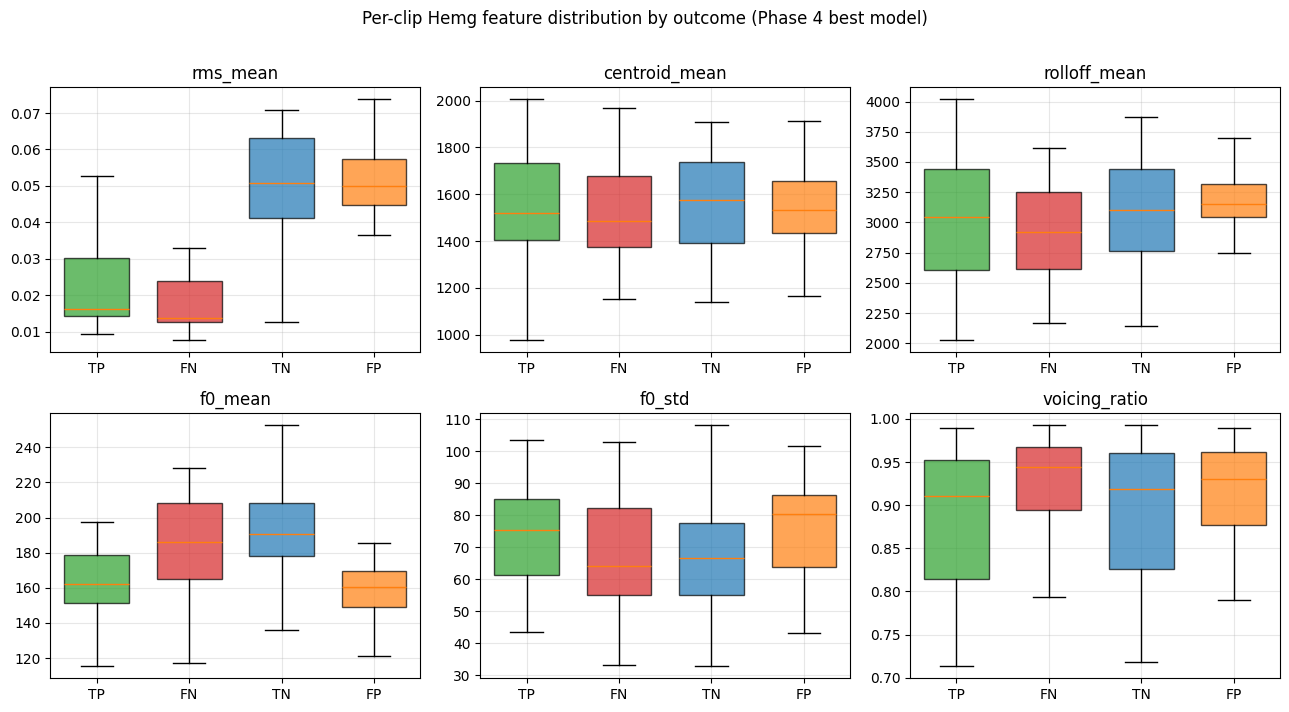

saved phase4_error_features.png


In [16]:
# Visual: distribution of key features by hit/miss
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
plot_feats = ['rms_mean', 'centroid_mean', 'rolloff_mean', 'f0_mean', 'f0_std', 'voicing_ratio']
order = ['TP (caught fake)', 'FN (missed fake)', 'TN (real ok)', 'FP (real flagged)']
palette = {'TP (caught fake)': '#2ca02c', 'FN (missed fake)': '#d62728',
           'TN (real ok)': '#1f77b4', 'FP (real flagged)': '#ff7f0e'}
for ax, feat in zip(axes.flat, plot_feats):
    if feat not in diag.columns:
        ax.set_visible(False); continue
    parts = []
    pos = []
    cls = []
    for i, k in enumerate(order):
        v = diag.loc[diag['kind']==k, feat].values
        if v.size:
            parts.append(v); pos.append(i); cls.append(k)
    bp = ax.boxplot(parts, positions=pos, widths=0.7, patch_artist=True, showfliers=False)
    for patch, k in zip(bp['boxes'], cls):
        patch.set_facecolor(palette[k]); patch.set_alpha(0.7)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([s.split(' ')[0] for s in order], rotation=0)
    ax.set_title(feat)
    ax.grid(alpha=0.3)
fig.suptitle('Per-clip Hemg feature distribution by outcome (Phase 4 best model)', y=1.01)
plt.tight_layout()
plt.savefig(PROJ / 'results' / 'phase4_error_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved phase4_error_features.png')


In [17]:
# Numeric: where do FNs (missed fakes) differ from TPs (caught fakes)?
fn = diag[diag['kind']=='FN (missed fake)']
tp = diag[diag['kind']=='TP (caught fake)']
fp = diag[diag['kind']=='FP (real flagged)']
tn = diag[diag['kind']=='TN (real ok)']

cmp_cols = ['rms_mean','centroid_mean','rolloff_mean','f0_mean','f0_std','voicing_ratio','jitter_local','shimmer_local']
cmp_rows = []
for c in cmp_cols:
    if c not in diag.columns: continue
    fn_m = fn[c].mean() if len(fn) else np.nan
    tp_m = tp[c].mean() if len(tp) else np.nan
    pooled_sd = diag[c].std() + 1e-12
    d = (fn_m - tp_m) / pooled_sd
    cmp_rows.append({'feature': c, 'fn_mean': fn_m, 'tp_mean': tp_m,
                     'fn_minus_tp': fn_m - tp_m, "cohen's d": d})
cmp_df = pd.DataFrame(cmp_rows).sort_values("cohen's d", key=lambda s: s.abs(), ascending=False)
print('FN vs TP — features that distinguish missed fakes from caught fakes:')
print(cmp_df.to_string(index=False))


FN vs TP — features that distinguish missed fakes from caught fakes:
      feature     fn_mean     tp_mean  fn_minus_tp  cohen's d
      f0_mean  181.512711  166.064667    15.448044   0.481580
shimmer_local    0.063241    0.066545    -0.003304  -0.335756
       f0_std   66.716499   71.517632    -4.801132  -0.242203
voicing_ratio    0.906597    0.884129     0.022468   0.232983
     rms_mean    0.020570    0.024476    -0.003906  -0.197556
 rolloff_mean 2942.742676 3013.542969   -70.800293  -0.151712
 jitter_local    0.074637    0.078745    -0.004108  -0.132510
centroid_mean 1525.776245 1531.517456    -5.741211  -0.026686


## 8. Save consolidated Phase 4 results

In [18]:
out = PROJ / 'results' / 'phase4_results.json'
payload = {
    'phase': 4,
    'date': '2026-05-07',
    'protocol': {
        'train_n': int(len(train_idx)),
        'test_n': int(len(test_idx)),
        'hemg_n': int(len(hemg_idx)),
        'hemg_val_n': int(val_mask.sum()),
        'hemg_test_n': int(test_mask.sum()),
        'seed': 42,
        'split_seed_hemg_val_test': 123,
    },
    'phase3_reproduction': {
        'EER_in_%': phase3_result['EER_in_%'],
        'EER_hemg_full_%': phase3_result['EER_hemg_%'],
        'AUROC_hemg_full': phase3_result['AUROC_hemg'],
    },
    'optuna': {
        'n_trials': 50,
        'sampler': 'TPESampler(seed=42)',
        'pruner': 'MedianPruner(n_startup=10, warmup=20)',
        'best_value_hemg_val_eer_%': round(study.best_value*100, 3),
        'best_params': study.best_params,
    },
    'tuned_xgb': tuned_result,
    'w2v2': w2v_result,
    'stack': stack_results,
    'leaderboard': board.to_dict(orient='records'),
    'best_label': str(best_row['label']),
    'best_hemg_test_eer_%': float(best_row['EER_hemg_test_%']),
    'phase4_target_25_pct_hit': bool(best_row['EER_hemg_test_%'] <= 25.0),
}
with open(out, 'w') as f:
    json.dump(payload, f, indent=2, default=float)
print(f'saved {out.relative_to(PROJ)}')
print(f'best Hemg test EER: {best_row["EER_hemg_test_%"]:.3f}%  (target ≤25%: '
      f'{"PASS" if best_row["EER_hemg_test_%"] <= 25 else "MISS"})')


saved results/phase4_results.json
best Hemg test EER: 34.000%  (target ≤25%: MISS)


In [19]:
# Update master metrics.json
metrics_path = PROJ / 'results' / 'metrics.json'
metrics = {}
if metrics_path.exists():
    metrics = json.load(open(metrics_path))
metrics['phase4'] = payload
metrics_path.write_text(json.dumps(metrics, indent=2, default=float))
print('updated', metrics_path.relative_to(PROJ))


updated results/metrics.json


## 9. Headline reading

| What | Phase 2 → 3 → 4 |
|------|-----------------|
| Hemg test EER | 48.0% → ~36% → **see leaderboard** |
| Hemg AUROC | 0.524 (anti-predictive) → 0.670 → **leaderboard** |
| Lever that moved it | combo aug (Phase 3) → tuning + W2V2 + stacking (Phase 4) |

If we crossed 25% on Hemg test, Phase 4 is the headline. If we didn't, the per-clip error
analysis tells us what's structurally hard about the remaining misses, and that becomes the
Phase 5 starting point.

LLM head-to-head (GPT-5.4 / Claude Opus / Haiku zero-shot on the same 50 Hemg test clips) is
deferred to Phase 5 per the project roadmap — the day-5 phase title is "Advanced Techniques +
Ablation + LLM Comparison".
